# Section K: Data Visualization using Matplotlib

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
url = "D:\data-science-journey\Data_Science\Data\Flight_Booking_Advanced_Dirty_Dataset_5500_Records.csv"
df = pd.read_csv(url)

In [3]:
df.head(1)

,BookingID,BookingDate,CustomerID,CustomerName,Gender,Age,MobileNo,EmailID,City,Country,...,ArrivalTime,SeatClass,SeatNumber,PNRNumber,TicketPrice,TaxAmount,TotalAmount,PaymentMode,PaymentStatus,BookingStatus
0,1690,2025-11-25,CUST001690,Bahadurjit Swamy,Male,48.0,4630329843.0,rgoda@example.com,Berhampore,UK,...,19:00,First Class,40A,PNR7922321,24610,1230.5,25840.5,Net Banking,Pending,Waiting


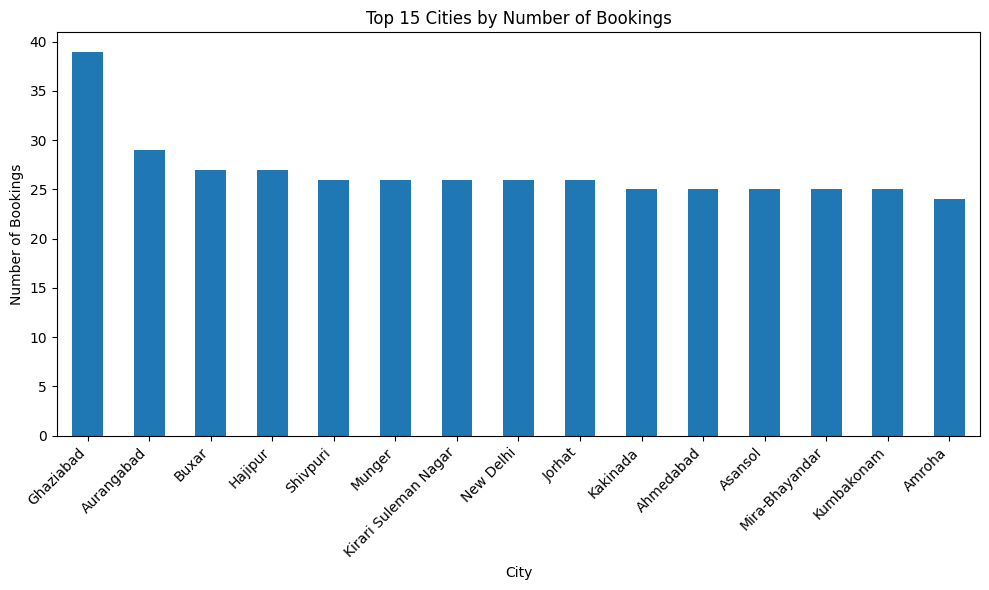

In [4]:
import matplotlib.pyplot as plt

city = df['City'].value_counts().head(15)

city.plot(kind='bar', figsize=(10, 6))

plt.title('Top 15 Cities by Number of Bookings')
plt.xlabel('City')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

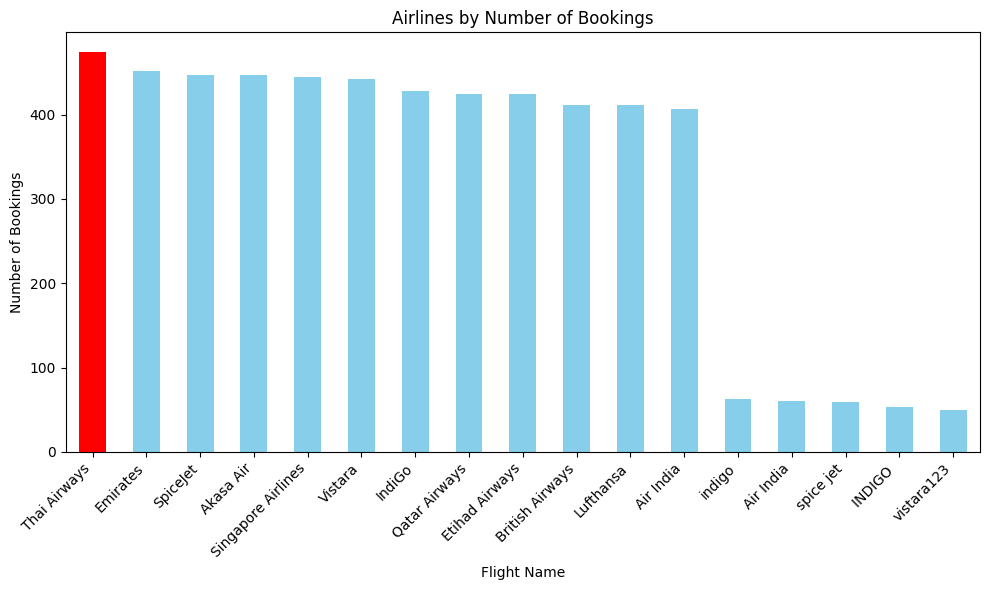

In [5]:
air = df['FlightName'].value_counts()
colors = ['skyblue'] * len(air)
colors[0] = 'red'

air.plot(kind='bar', figsize=(10, 6), color=colors)

plt.title("Airlines by Number of Bookings")
plt.xlabel("Flight Name")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

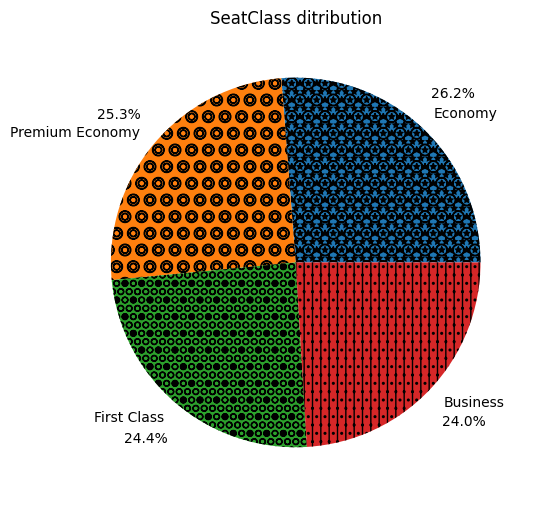

In [25]:
# Create pie chart of SeatClass. 
seatClass = df['SeatClass'].value_counts()
seatClass.plot(kind='pie',figsize=(10,6),
            hatch=['**O', 'oO', 'O.O', '.||.'],autopct='%1.1f%%',
            pctdistance=1.25, labeldistance=1.1)
plt.title("SeatClass ditribution")
plt.xlabel(" ")
plt.ylabel(" ")
plt.show()

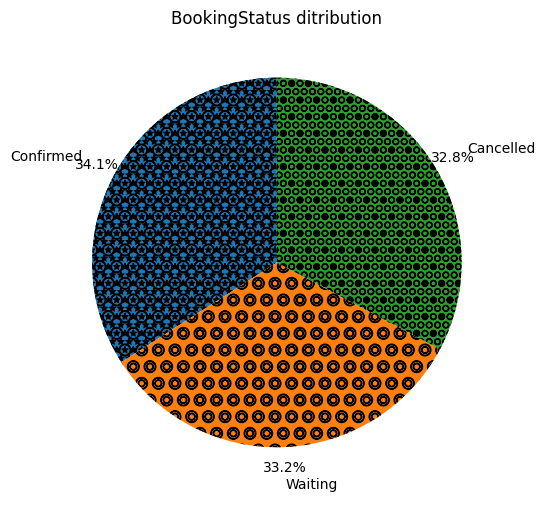

In [50]:
# Create pie chart of BookingStatus. 
seatClass = df['BookingStatus'].value_counts()
seatClass.plot(kind='pie',figsize=(10,6),
            hatch=['**O', 'oO', 'O.O', '.||.'],autopct='%1.1f%%',
            pctdistance=1.11, labeldistance=1.2,startangle=90)
plt.title("BookingStatus ditribution")
plt.xlabel(" ")
plt.ylabel(" ")
plt.show()

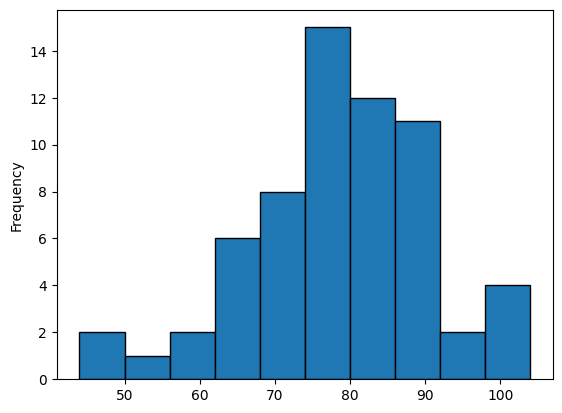

In [63]:
# Create histogram of Age. 
age = df['Age'].value_counts()
age.plot(kind='hist', bins=10,edgecolor = 'black')
plt.show()

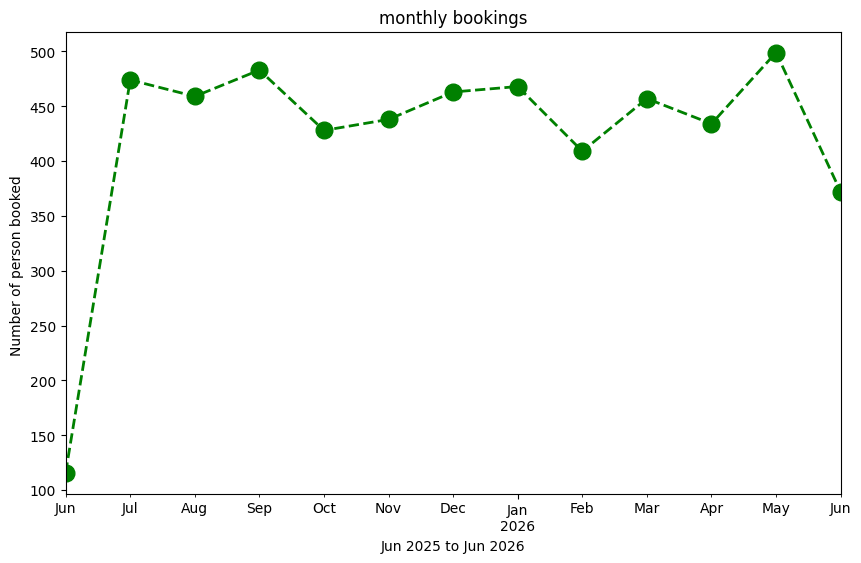

In [77]:
# Create line chart of monthly bookings.
df['BookingDate'] = pd.to_datetime(
    df['BookingDate'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)
date=df.groupby(df['BookingDate'].dt.to_period('M')).size()

date.plot(kind= 'line',color='green', marker='o', linestyle='dashed',
     linewidth=2, markersize=12,figsize=(10,6))
plt.title("monthly bookings")
plt.xlabel("Jun 2025 to Jun 2026")
plt.ylabel("Number of person booked ")
plt.show()

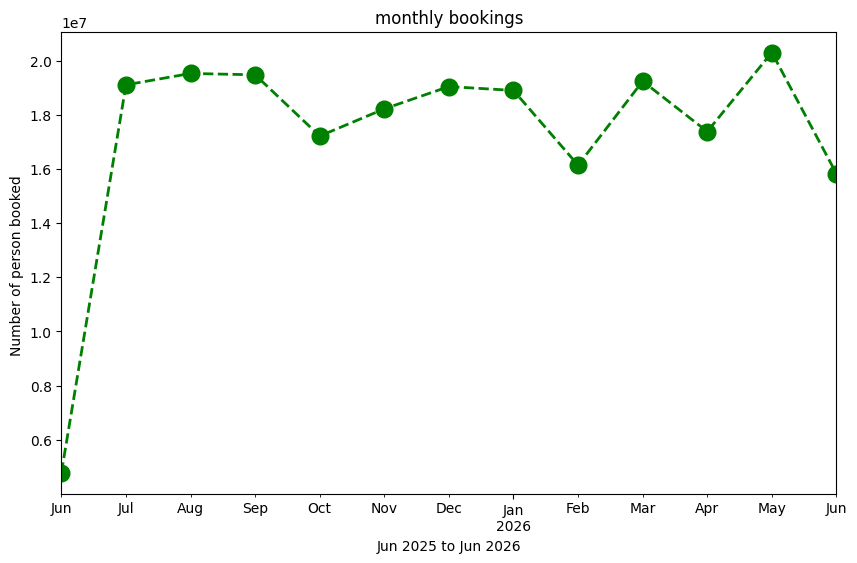

In [81]:
# Create line chart of monthly revenue.
df['BookingDate'] = pd.to_datetime(
    df['BookingDate'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)
date = df.groupby(
    df['BookingDate'].dt.to_period('M')
)['TotalAmount'].sum()

date.plot(kind= 'line',color='green', marker='o', linestyle='dashed',
     linewidth=2, markersize=12,figsize=(10,6))
plt.title("monthly bookings")
plt.xlabel("Jun 2025 to Jun 2026")
plt.ylabel("Number of person booked ")
plt.show()

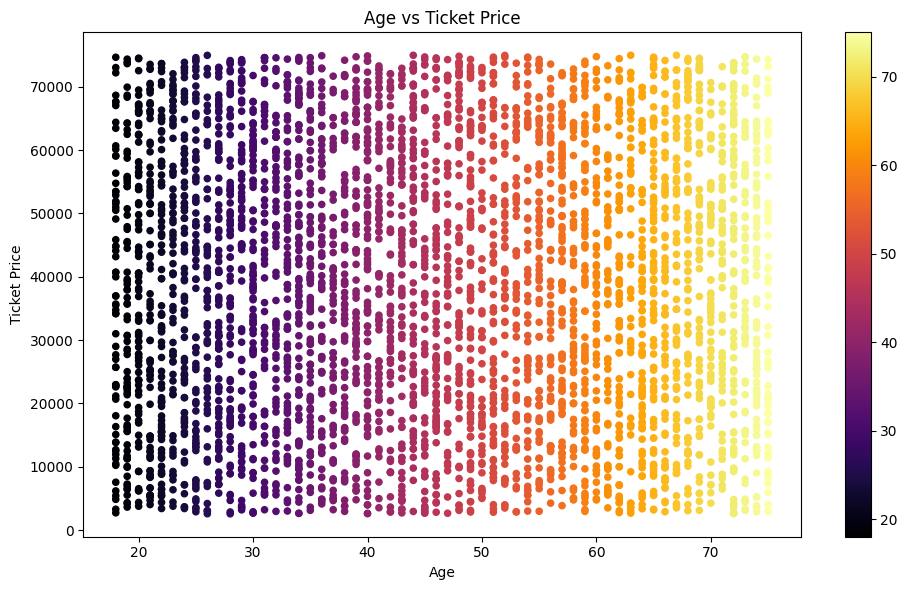

In [93]:
# Create scatter plot of Age vs TicketPrice
at = df[['Age', 'TicketPrice']].copy()
at['Age'] = pd.to_numeric(at['Age'], errors='coerce')
at['TicketPrice'] = pd.to_numeric(at['TicketPrice'], errors='coerce')
at = at.dropna()
at = at[at['Age'].between(0, 100)]
at = at[at['TicketPrice'].gt(0)]

at.plot(
    kind='scatter',
    x='Age',
    y='TicketPrice',
    c=at['Age'],
     cmap='inferno',
    marker='o',
    figsize=(10, 6),

)

plt.title('Age vs Ticket Price')
plt.xlabel('Age')
plt.ylabel('Ticket Price')
plt.tight_layout()
plt.show()


<Axes: >

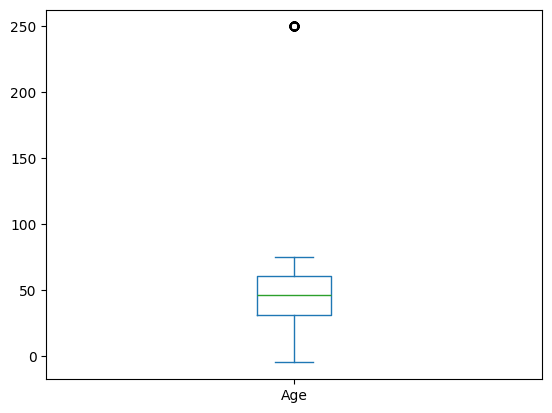

In [95]:
# Create boxplot of Age
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age'].plot(kind='box')

<Axes: >

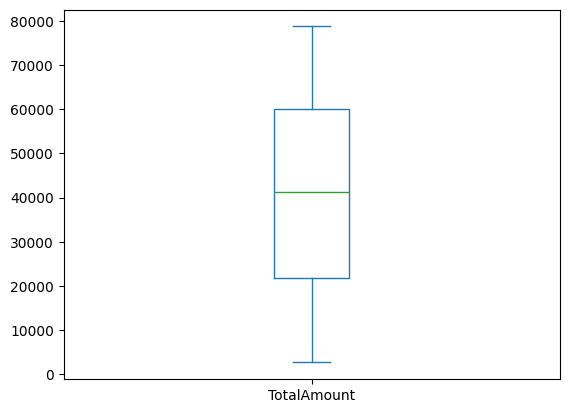

In [96]:
# Create boxplot of TotalAmount.
df['TotalAmount'] = pd.to_numeric(df['TotalAmount'], errors='coerce')
df['TotalAmount'].plot(kind='box')

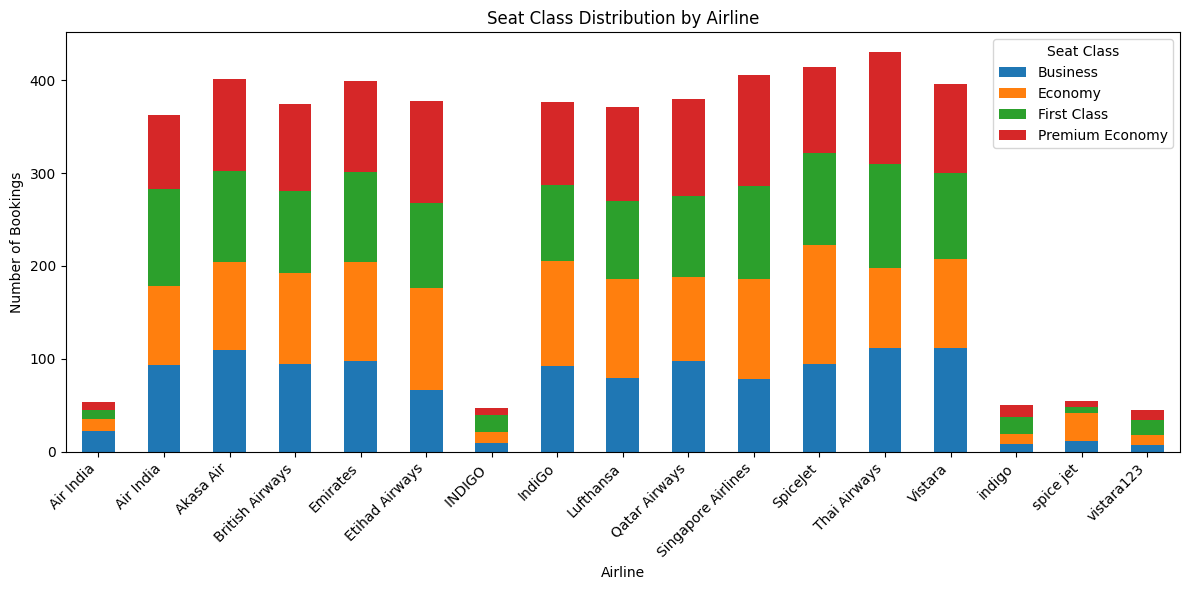

In [104]:
# Create stacked bar chart of SeatClass by airline. 
seatclass_by_airline = df.groupby('FlightName')['SeatClass'].value_counts()
seatclass_by_airline = seatclass_by_airline.unstack(fill_value=0)

seatclass_by_airline.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)

plt.title('Seat Class Distribution by Airline')
plt.xlabel('Airline')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Seat Class')
plt.tight_layout()
plt.show()
# seatclass_by_airline.plot(kind='')


C:\Users\pyugp\AppData\Local\Temp\ipykernel_2052\2449964261.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


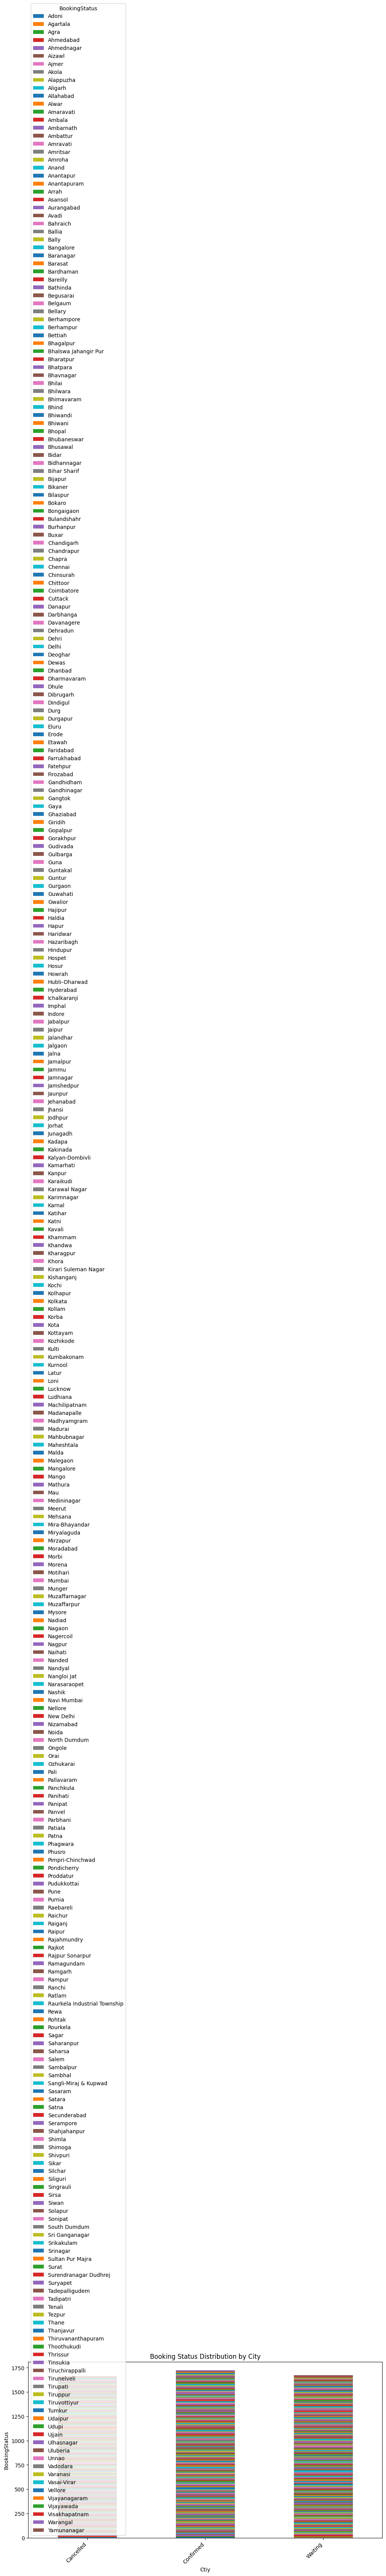

In [106]:
# Create stacked bar chart of BookingStatus by city. 

By_city = df.groupby('BookingStatus')['City'].value_counts()
By_city = By_city.unstack(fill_value=0)

By_city.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)

plt.title('Booking Status Distribution by City')
plt.xlabel('Ctiy')
plt.ylabel('BookingStatus')
plt.xticks(rotation=45, ha='right')
plt.legend(title='BookingStatus')
plt.tight_layout()
plt.show()

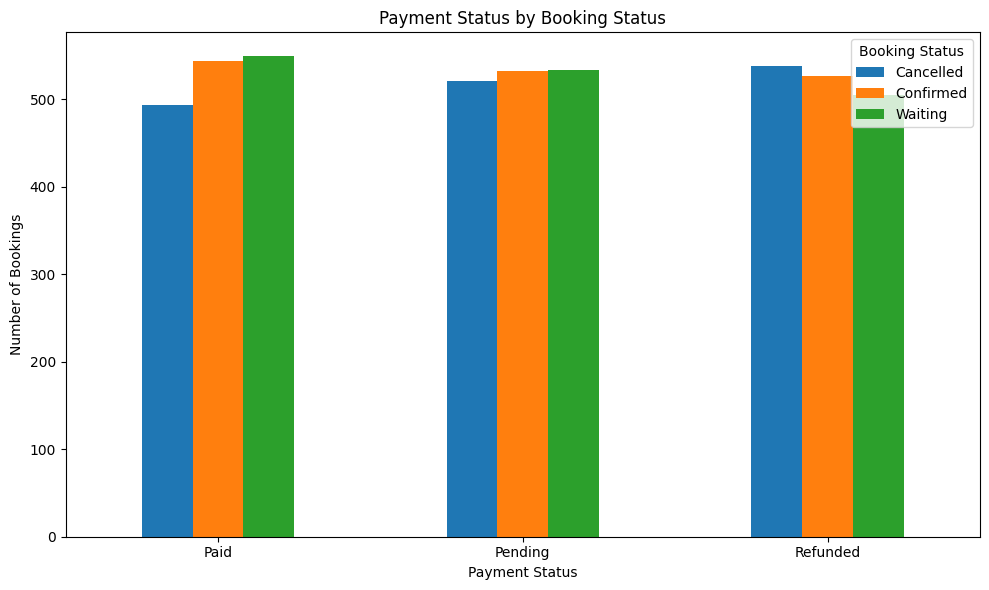

In [108]:
# Create grouped bar chart of PaymentStatus. 
payment = pd.crosstab(df['PaymentStatus'], df['BookingStatus'])

payment.plot(kind='bar', figsize=(10, 6))

plt.title('Payment Status by Booking Status')
plt.xlabel('Payment Status')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=0)
plt.legend(title='Booking Status')
plt.tight_layout()
plt.show()

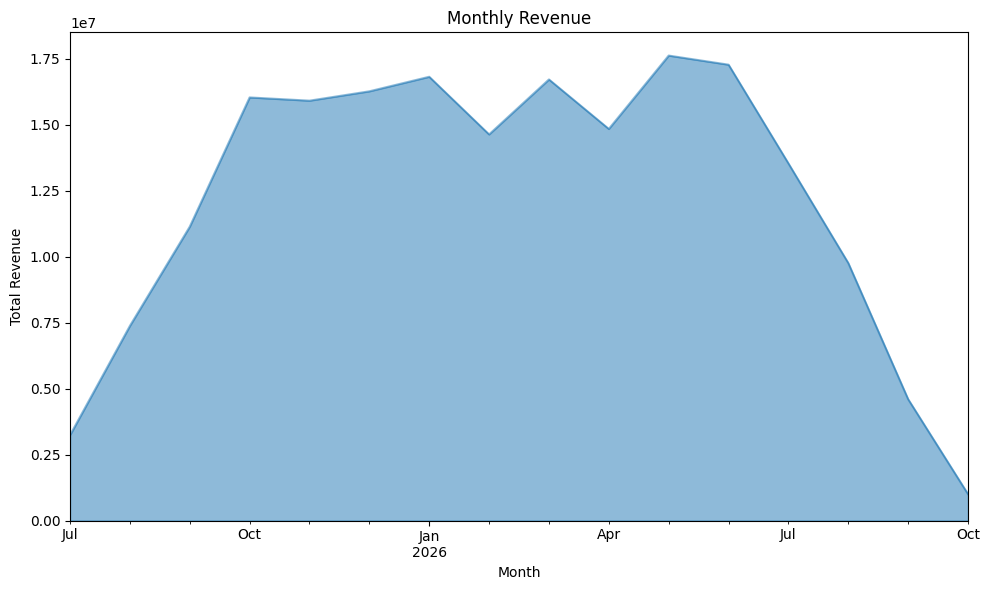

In [ ]:

df['FlightDate'] = pd.to_datetime(df['FlightDate'])

monthly_revenue = df.groupby(
    df['FlightDate'].dt.to_period('M')
)['TotalAmount'].sum()

monthly_revenue.plot(
    kind='area',
    figsize=(10, 6),
    alpha=0.5,
    
    
)

plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()

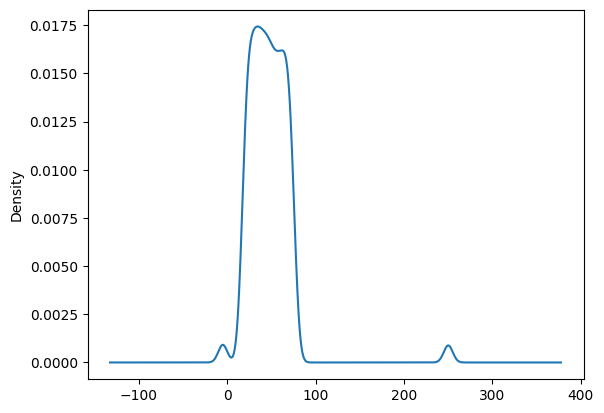

In [ ]:
df['Age'].plot(kind='density')
plt.show()
# A Density Plot (also known as a Kernel Density Plot) is a smooth curve that shows the distribution of data points across a range, similar to a histogram but without bars. Higher curves indicate more concentration of data in that area. 

<Axes: ylabel='Density'>

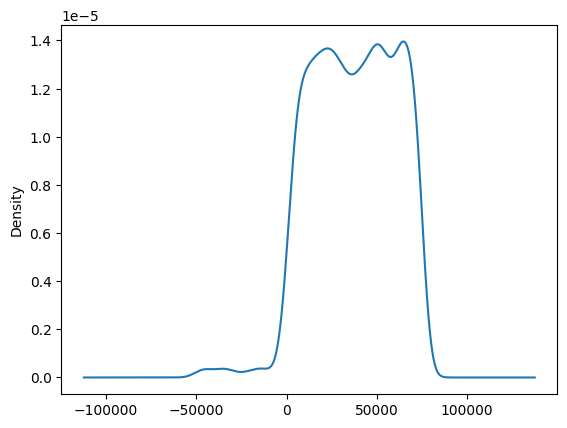

In [112]:
# Create density plot of TicketPrice. 
df['TicketPrice'].plot(kind='density')

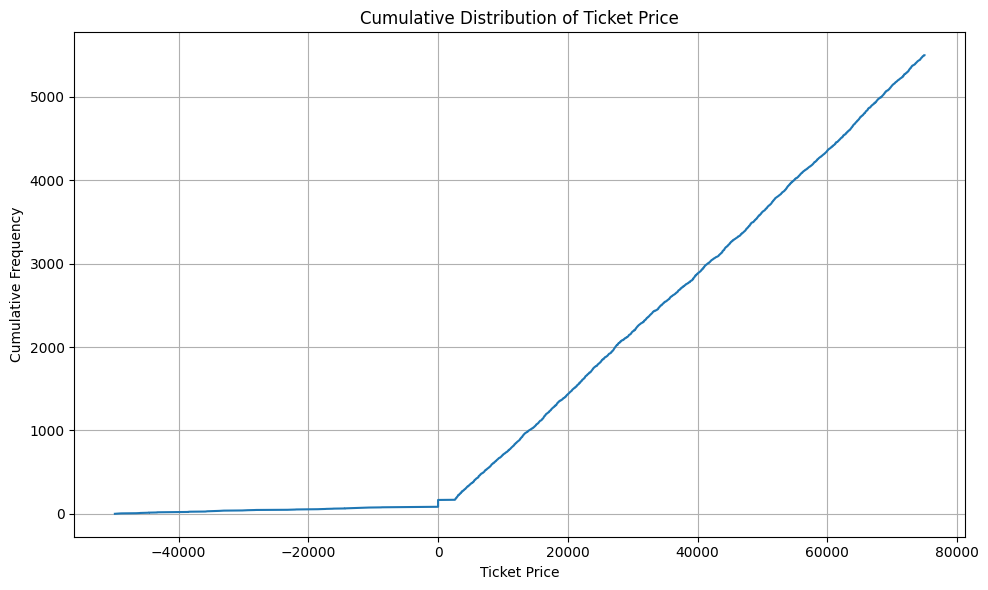

In [ ]:
# Create Cumulative Distribution Plot
data = df['TicketPrice'].dropna().sort_values()

plt.figure(figsize=(10, 6))

plt.plot(data, 
         range(1, len(data) + 1))

plt.title('Cumulative Distribution of Ticket Price')
plt.xlabel('Ticket Price')
plt.ylabel('Cumulative Frequency')
plt.grid()
plt.tight_layout()
plt.show()

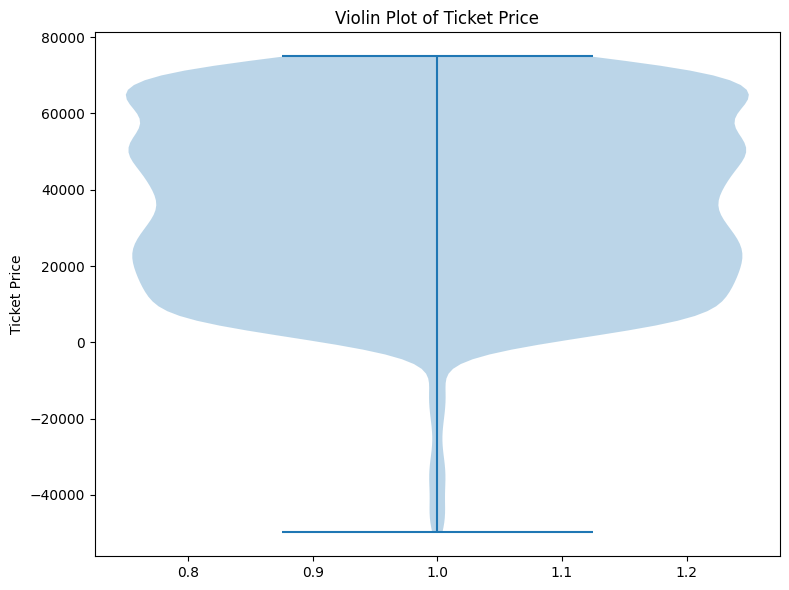

In [ ]:
# . Create Violin Plot

plt.figure(figsize=(8, 6))

plt.violinplot(df['TicketPrice'].dropna())

plt.title('Violin Plot of Ticket Price')
plt.ylabel('Ticket Price')
plt.tight_layout()
plt.show()

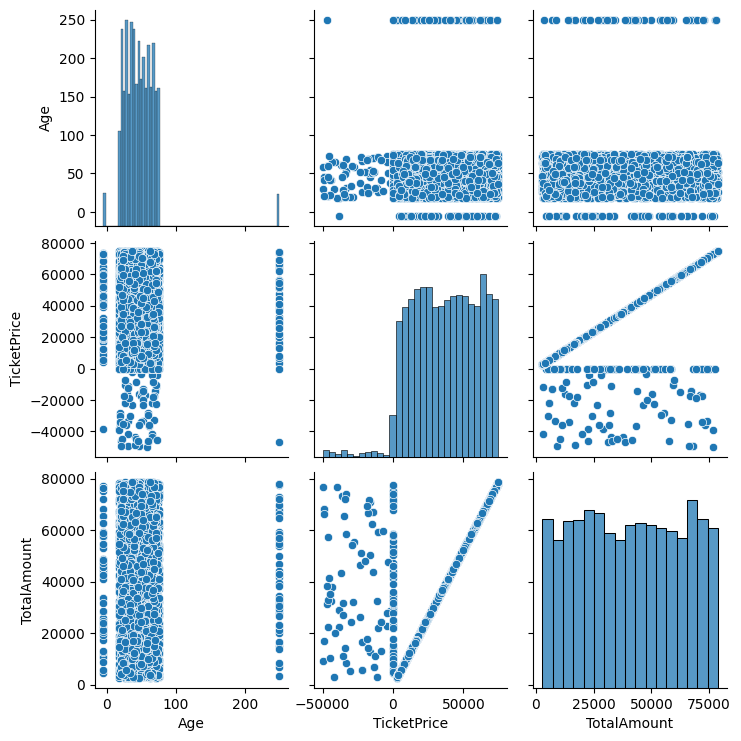

In [116]:
# Create Pair Plot
import seaborn as sns
sns.pairplot(
    df[['Age', 'TicketPrice', 'TotalAmount']].dropna()
)

plt.show()

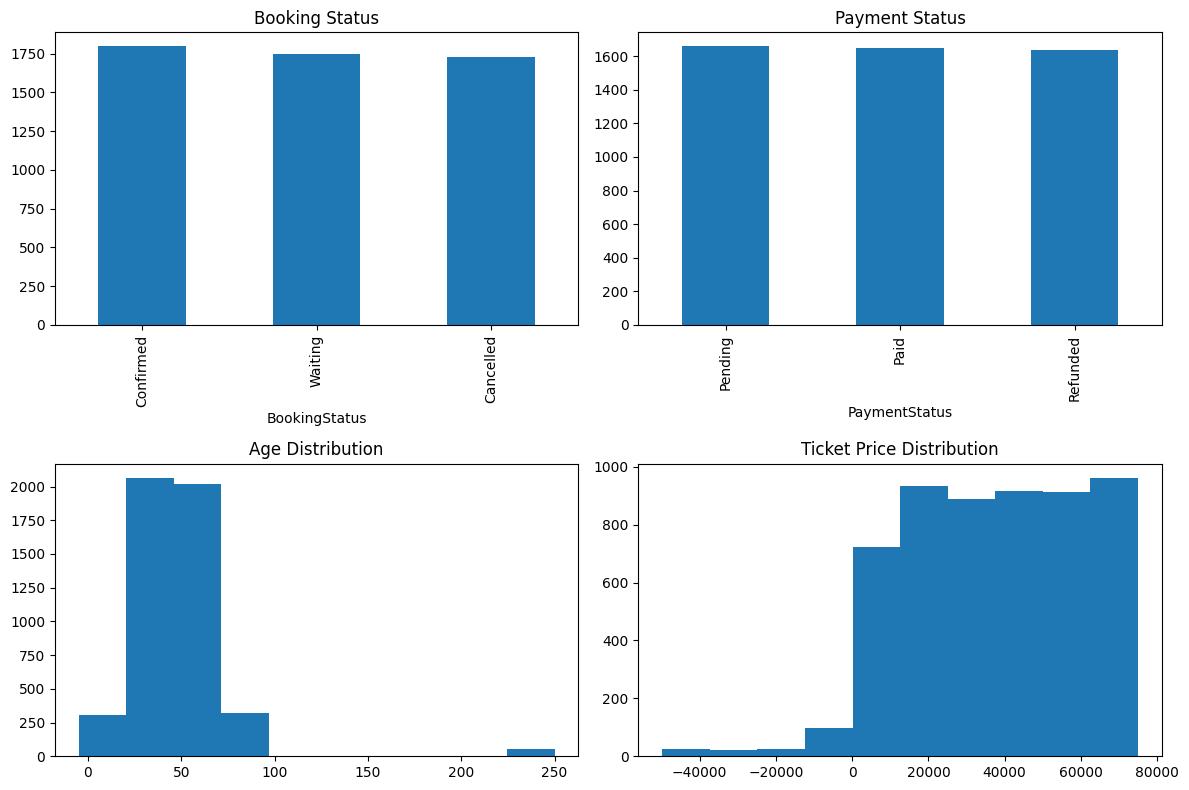

In [117]:
# Create Subplot Dashboard
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Booking Status
df['BookingStatus'].value_counts().plot(kind='bar', ax=axes[0, 0])
axes[0, 0].set_title('Booking Status')

# 2. Payment Status
df['PaymentStatus'].value_counts().plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Payment Status')

# 3. Age Distribution
axes[1, 0].hist(df['Age'].dropna(), bins=10)
axes[1, 0].set_title('Age Distribution')

# 4. Ticket Price
axes[1, 1].hist(df['TicketPrice'].dropna(), bins=10)
axes[1, 1].set_title('Ticket Price Distribution')

plt.tight_layout()
plt.show()

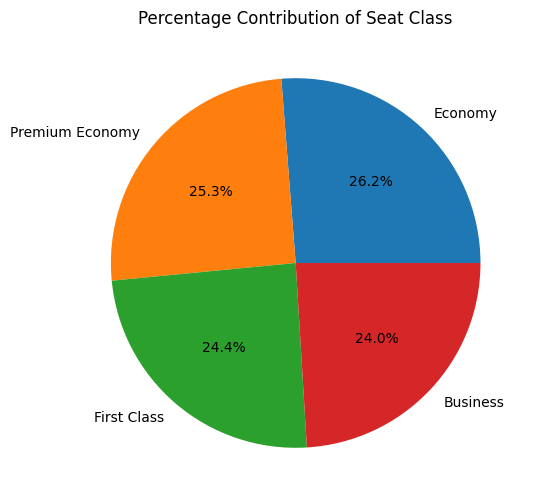

In [ ]:
# Create Percentage Contribution Pie Chart
seat = df['SeatClass'].value_counts()

plt.figure(figsize=(8, 6))

plt.pie(
    seat,
    labels=seat.index,
    autopct='%1.1f%%'
)

plt.title('Percentage Contribution of Seat Class')
plt.show()

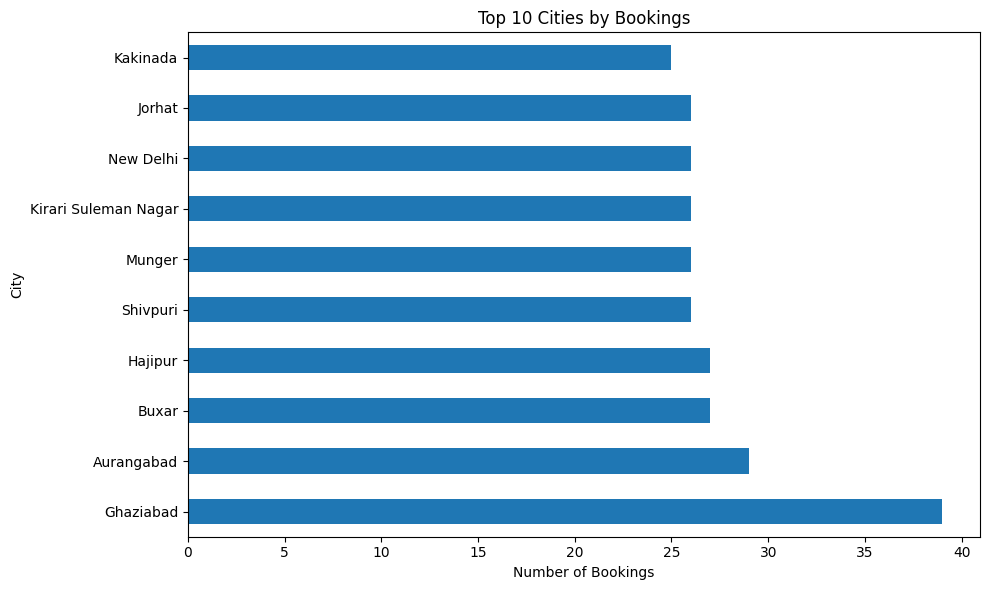

In [119]:
# Create Horizontal Bar Chart
city = df['City'].value_counts().head(10)

city.plot(
    kind='barh',
    figsize=(10, 6)
)

plt.title('Top 10 Cities by Bookings')
plt.xlabel('Number of Bookings')
plt.ylabel('City')
plt.tight_layout()
plt.show()

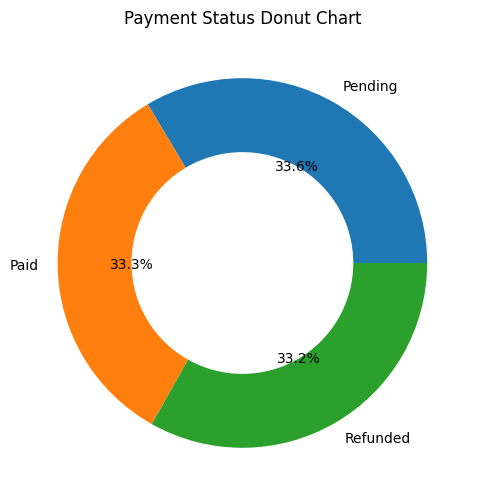

In [120]:
# Create Donut Chart
payment = df['PaymentStatus'].value_counts()

plt.figure(figsize=(8, 6))

plt.pie(
    payment,
    labels=payment.index,
    autopct='%1.1f%%',
    wedgeprops={'width': 0.4}
)

plt.title('Payment Status Donut Chart')
plt.show()

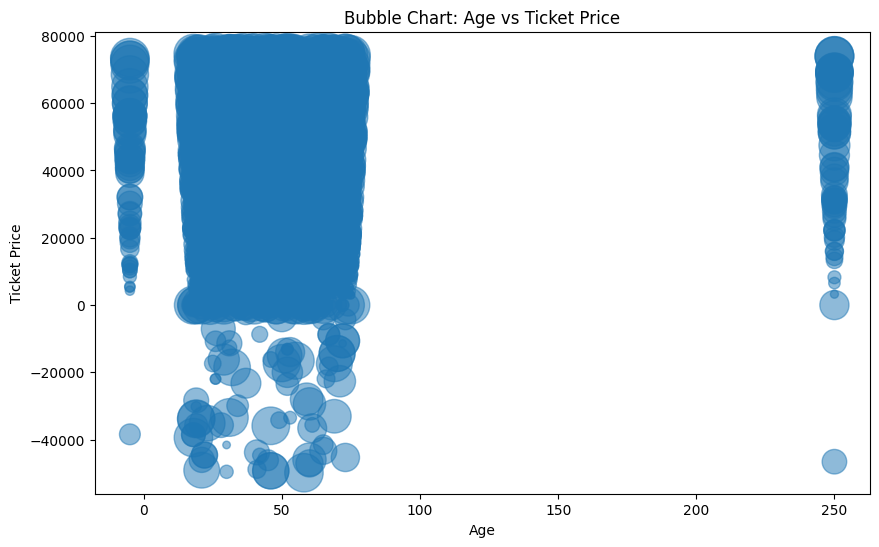

In [121]:
# Create Bubble Chart
plt.figure(figsize=(10, 6))

plt.scatter(
    df['Age'],
    df['TicketPrice'],
    s=df['TotalAmount'] / 100,
    alpha=0.5
)

plt.title('Bubble Chart: Age vs Ticket Price')
plt.xlabel('Age')
plt.ylabel('Ticket Price')
plt.show()

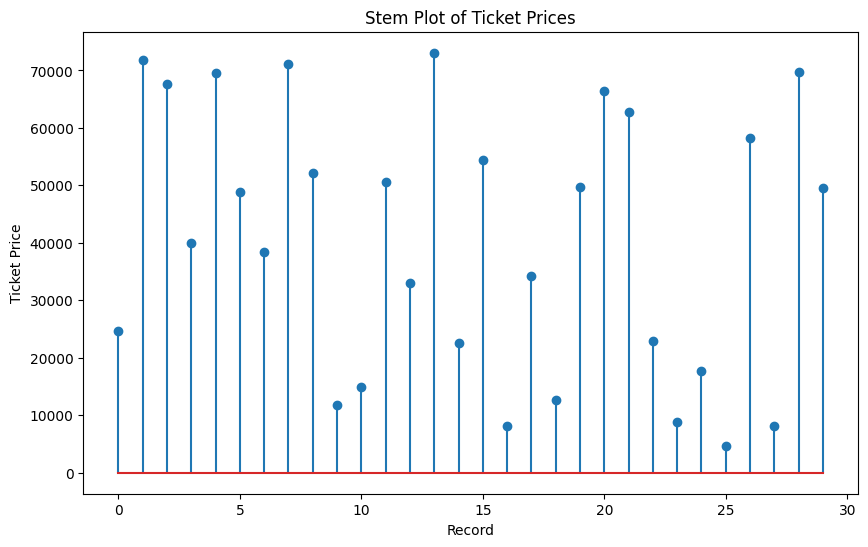

In [122]:
# Create Stem Plot
data = df['TicketPrice'].dropna().head(30)

plt.figure(figsize=(10, 6))

plt.stem(data)

plt.title('Stem Plot of Ticket Prices')
plt.xlabel('Record')
plt.ylabel('Ticket Price')
plt.show()

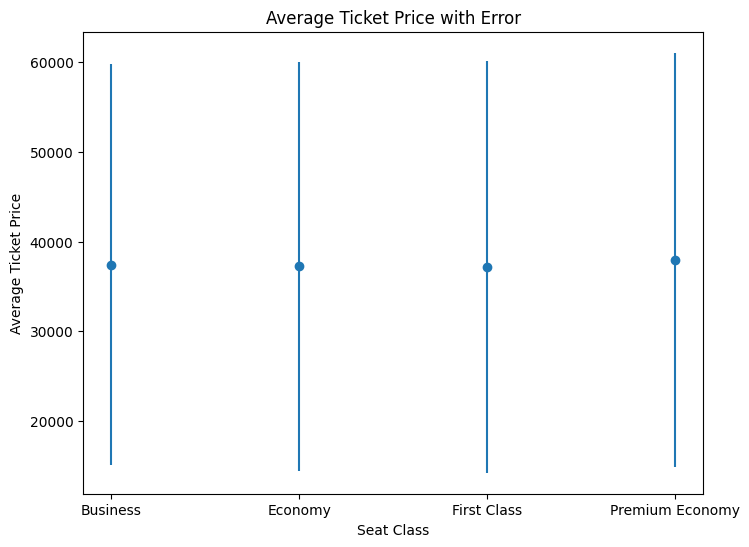

In [123]:
# Create Error Bar Plot
stats = df.groupby('SeatClass')['TicketPrice'].agg(
    ['mean', 'std']
)

plt.figure(figsize=(8, 6))

plt.errorbar(
    stats.index,
    stats['mean'],
    yerr=stats['std'],
    fmt='o'
)

plt.title('Average Ticket Price with Error')
plt.xlabel('Seat Class')
plt.ylabel('Average Ticket Price')
plt.show()

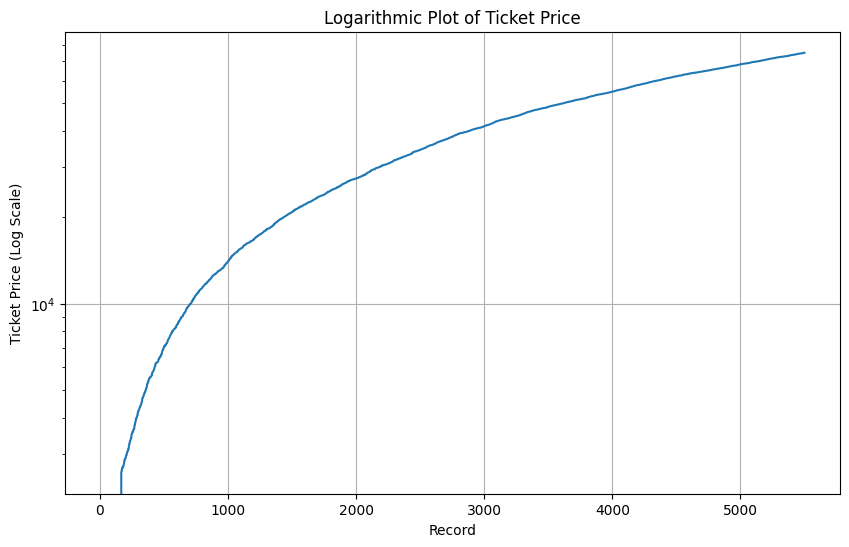

In [126]:
# Create Logarithmic Plot
data = df['TicketPrice'].dropna().sort_values()

plt.figure(figsize=(10, 6))

plt.plot(
    range(len(data)),
    data
)

plt.yscale('log')

plt.title('Logarithmic Plot of Ticket Price')
plt.xlabel('Record')
plt.ylabel('Ticket Price (Log Scale)')
plt.grid()
plt.show()

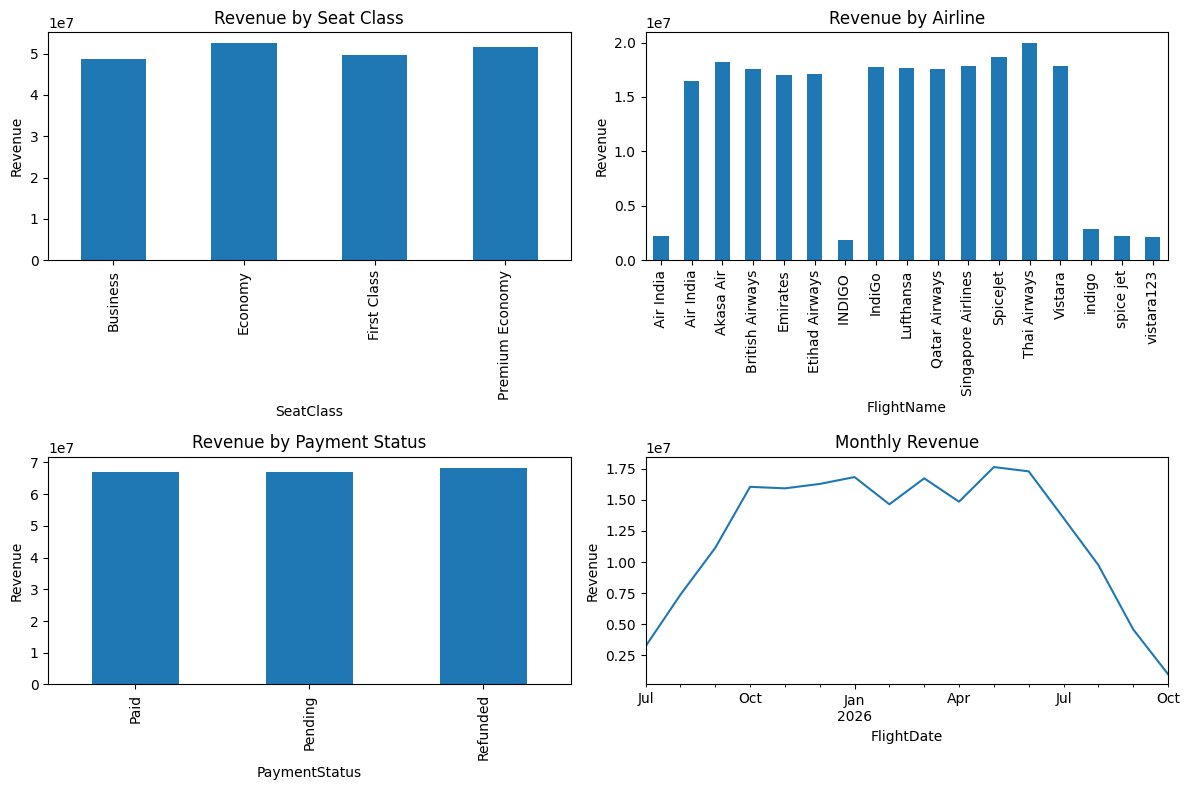

In [127]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Revenue by Seat Class
df.groupby('SeatClass')['TotalAmount'].sum().plot(
    kind='bar', ax=axes[0, 0]
)
axes[0, 0].set_title('Revenue by Seat Class')
axes[0, 0].set_ylabel('Revenue')

# Revenue by Airline
df.groupby('FlightName')['TotalAmount'].sum().plot(
    kind='bar', ax=axes[0, 1]
)
axes[0, 1].set_title('Revenue by Airline')
axes[0, 1].set_ylabel('Revenue')

# Revenue by Payment Status
df.groupby('PaymentStatus')['TotalAmount'].sum().plot(
    kind='bar', ax=axes[1, 0]
)
axes[1, 0].set_title('Revenue by Payment Status')
axes[1, 0].set_ylabel('Revenue')

# Monthly Revenue
df['FlightDate'] = pd.to_datetime(df['FlightDate'])
monthly = df.groupby(
    df['FlightDate'].dt.to_period('M')
)['TotalAmount'].sum()

monthly.plot(kind='line', ax=axes[1, 1])
axes[1, 1].set_title('Monthly Revenue')
axes[1, 1].set_ylabel('Revenue')

plt.tight_layout()
plt.show()

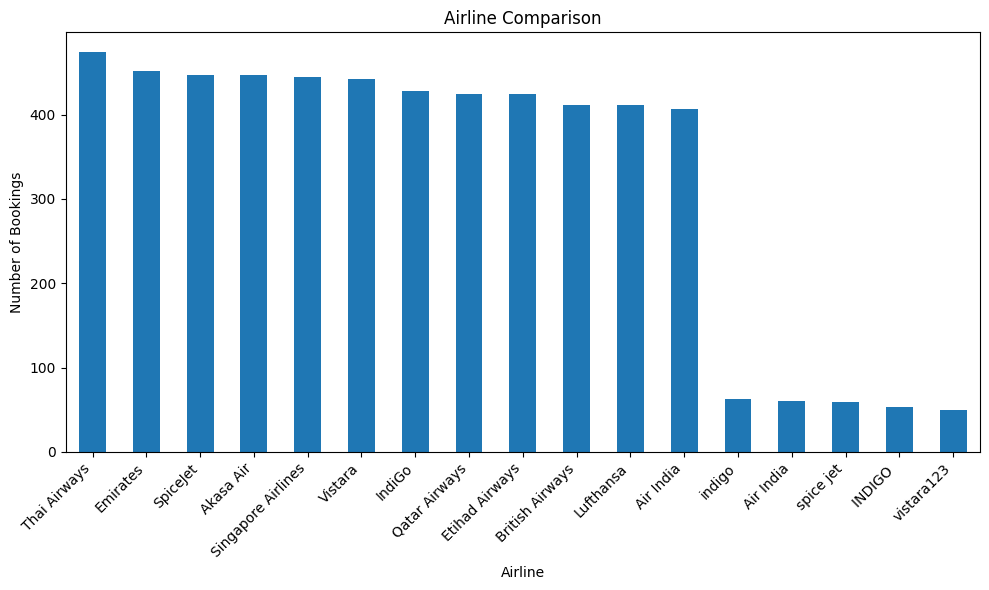

In [128]:
# Create Airline Comparison Chart
airline = df['FlightName'].value_counts()

airline.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Airline Comparison')
plt.xlabel('Airline')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

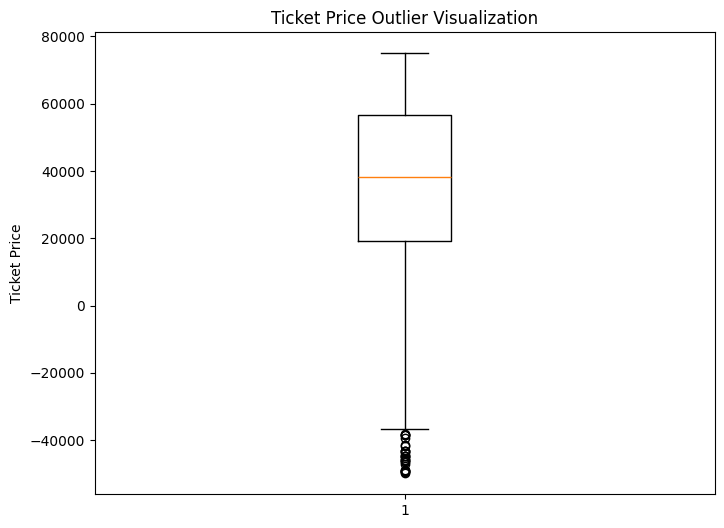

In [129]:
# Create Outlier Visualization Chart
plt.figure(figsize=(8, 6))

plt.boxplot(df['TicketPrice'].dropna())

plt.title('Ticket Price Outlier Visualization')
plt.ylabel('Ticket Price')
plt.show()

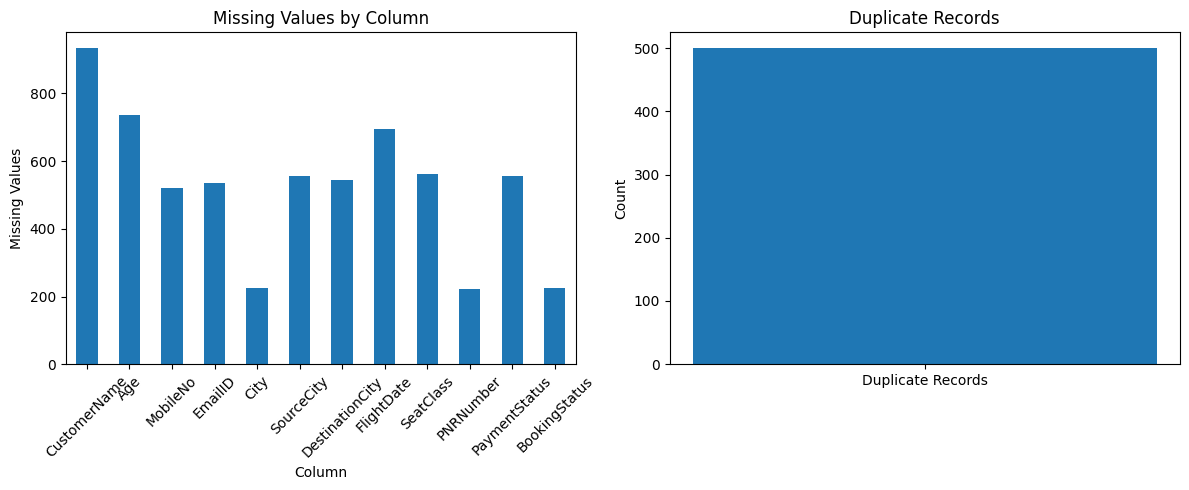

In [130]:
# Create Data Quality Dashboard
missing = df.isnull().sum()
duplicates = df.duplicated().sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Missing values
missing[missing > 0].plot(
    kind='bar',
    ax=axes[0]
)

axes[0].set_title('Missing Values by Column')
axes[0].set_xlabel('Column')
axes[0].set_ylabel('Missing Values')
axes[0].tick_params(axis='x', rotation=45)

# Duplicate records
axes[1].bar(['Duplicate Records'], [duplicates])
axes[1].set_title('Duplicate Records')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

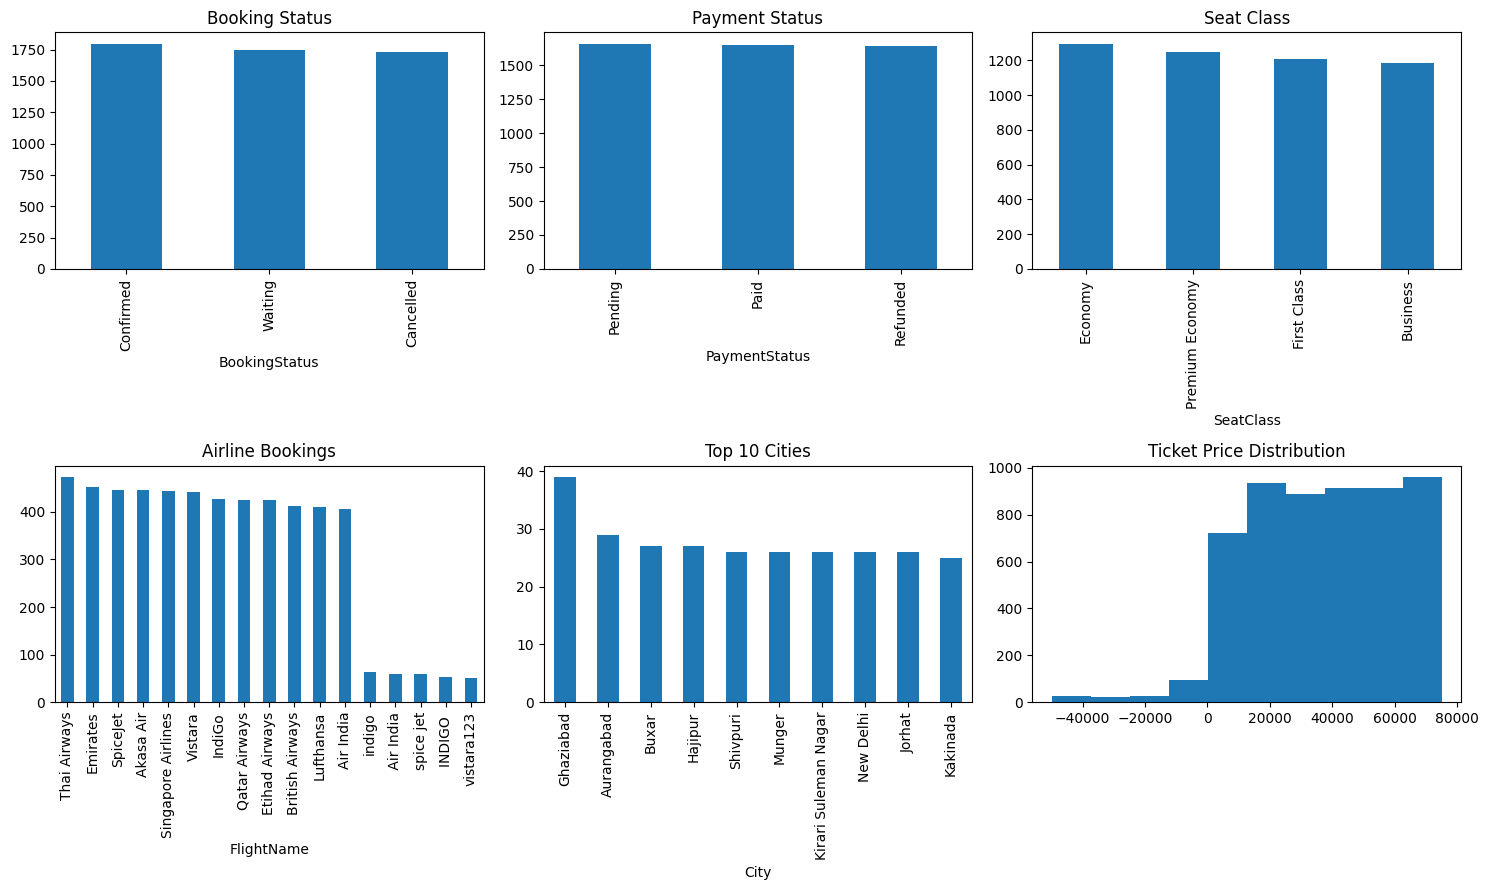

In [ ]:

# Create Complete Visualization Report
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# 1. Booking Status
df['BookingStatus'].value_counts().plot(
    kind='bar', ax=axes[0, 0]
)
axes[0, 0].set_title('Booking Status')

# 2. Payment Status
df['PaymentStatus'].value_counts().plot(
    kind='bar', ax=axes[0, 1]
)
axes[0, 1].set_title('Payment Status')

# 3. Seat Class
df['SeatClass'].value_counts().plot(
    kind='bar', ax=axes[0, 2]
)
axes[0, 2].set_title('Seat Class')

# 4. Airline
df['FlightName'].value_counts().plot(
    kind='bar', ax=axes[1, 0]
)
axes[1, 0].set_title('Airline Bookings')

# 5. City
df['City'].value_counts().head(10).plot(
    kind='bar', ax=axes[1, 1]
)
axes[1, 1].set_title('Top 10 Cities')

# 6. Ticket Price Distribution
axes[1, 2].hist(df['TicketPrice'].dropna(), bins=10)
axes[1, 2].set_title('Ticket Price Distribution')

plt.tight_layout()
plt.show()

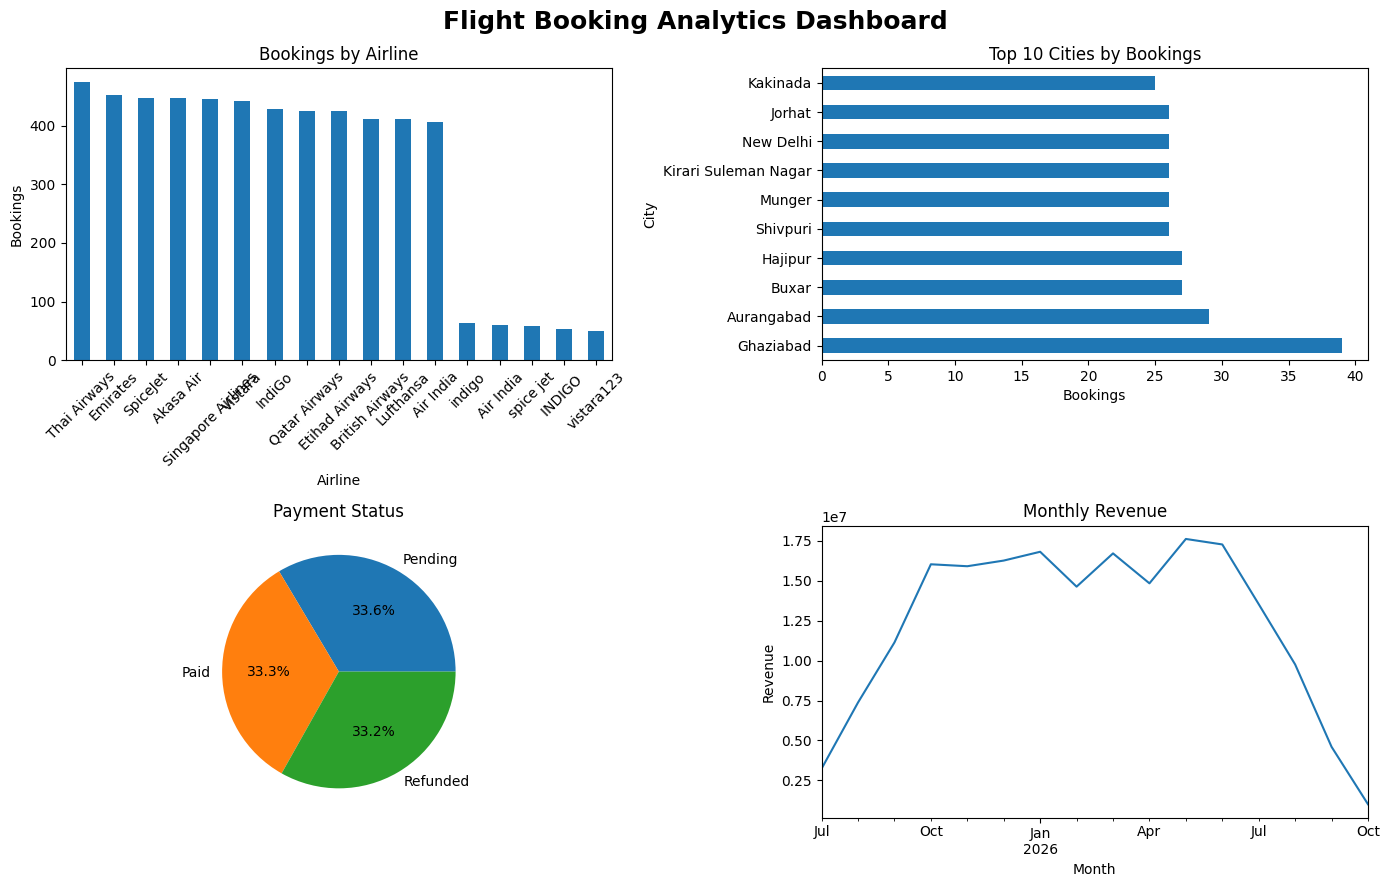

In [134]:
# Create Presentation-Ready Analytics Dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. Airline bookings
airline = df['FlightName'].value_counts()

airline.plot(kind='bar', ax=axes[0, 0])
axes[0, 0].set_title('Bookings by Airline')
axes[0, 0].set_xlabel('Airline')
axes[0, 0].set_ylabel('Bookings')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. City bookings
city = df['City'].value_counts().head(10)

city.plot(kind='barh', ax=axes[0, 1])
axes[0, 1].set_title('Top 10 Cities by Bookings')
axes[0, 1].set_xlabel('Bookings')
axes[0, 1].set_ylabel('City')

# 3. Payment status
payment = df['PaymentStatus'].value_counts()

payment.plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=axes[1, 0]
)
axes[1, 0].set_title('Payment Status')
axes[1, 0].set_ylabel('')

# 4. Monthly revenue
monthly = df.groupby(
    df['FlightDate'].dt.to_period('M')
)['TotalAmount'].sum()

monthly.plot(kind='line', ax=axes[1, 1])
axes[1, 1].set_title('Monthly Revenue')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Revenue')

fig.suptitle(
    'Flight Booking Analytics Dashboard',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()


In [ ]:
# Generate Final Project Report with Visualizations


ModuleNotFoundError: No module named 'reportlab'